<a href="https://colab.research.google.com/github/AashishStark/Vehicle-Pollution-Detection/blob/main/Prediction_of_Vehicle_and_Extraction_of_License_Plate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from keras.models import load_model
from keras.preprocessing.image import ImageDataGenerator,load_img
import numpy as np
from keras.preprocessing.image import load_img, img_to_array

test_datagen = ImageDataGenerator(rescale=1. / 255)

sevenModels = [load_model('/content/drive/MyDrive/models/ITERATION 4/iteration_4_1/model_InceptionV3_iteration4_1.h5'),
               load_model('/content/drive/MyDrive/models/ITERATION 4/iteration_4_1/model_ResNet50_iteration4_1.h5'),
               load_model('/content/drive/MyDrive/models/ITERATION 4/iteration_4_1/model_MobileNetV3Small_iteration4_1.h5'),
               load_model('/content/drive/MyDrive/models/ITERATION 4/iteration_4_1/model_InceptionResNetV2_iteration4_1.h5'),
               load_model('/content/drive/MyDrive/models/ITERATION 4/iteration_4_1/model_VGG16_iteration4_1.h5'),
               load_model('/content/drive/MyDrive/models/ITERATION 4/iteration_4_1/model_VGG19_iteration4_1.h5'),
               load_model('/content/drive/MyDrive/models/ITERATION 4/iteration_4_1/model_Xception_iteration4_1.h5')
              ]

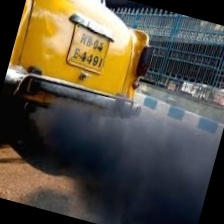

In [ ]:
image_path = '/content/drive/MyDrive/final_project/Dataset/DATASET1/WithPollution/rneg/rot_neg_15_Pol_7.jpg'
#image_path = '/content/drive/MyDrive/final_project/Dataset/DATASET1/WithoutPollution/flip/flip_NoPol_102.jpg'
#image_path='/content/drive/MyDrive/final_project/Dataset/car.jpg'
import PIL.Image

img = PIL.Image.open(image_path)
img

In [ ]:
pip install -q -U google-generativeai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.9/146.9 kB 2.3 MB/s eta 0:00:00


In [ ]:
import pathlib
import textwrap

import google.generativeai as genai
from google.colab import userdata

from IPython.display import display
from IPython.display import Markdown


def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

In [ ]:
GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')

genai.configure(api_key=GOOGLE_API_KEY)

In [ ]:
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    print(m.name)

models/gemini-pro
models/gemini-pro-vision


In [ ]:
genai_model = genai.GenerativeModel('gemini-pro-vision')

In [ ]:
image = load_img(image_path, target_size=(224, 224))

image_array = img_to_array(image)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)
predictionsList,predictedClassList=[],[]
for model in sevenModels:
  predictions = model.predict(image_array)
  predicted_class = np.argmax(predictions[0])
  predictionsList.append(predictions[0][predicted_class])
  predictedClassList.append(predicted_class)
  print("CLASS" + str(predicted_class))
  noZero=predictedClassList.count(0)
  noOne=predictedClassList.count(1)
  if noOne>noZero:
    finNo=1
  else:
    finNo=0

if finNo==1:
  print("Predicted as Without Pollution")
else:
  print("Predicted as With Pollution")

1/1 [==============================] - 2s 2s/step
CLASS0
1/1 [==============================] - 1s 1s/step
CLASS0
1/1 [==============================] - 2s 2s/step
CLASS0
1/1 [==============================] - 3s 3s/step
CLASS0
1/1 [==============================] - 1s 778ms/step
CLASS0
1/1 [==============================] - 1s 1s/step
CLASS0
1/1 [==============================] - 1s 1s/step
CLASS0
Predicted as With Pollution


In [ ]:
response = genai_model.generate_content(["Just extract the license plate from the image only from the car and give the output as 'License Plate:' and if the license plate is not visible give output as License Plate number is not visible", img], stream=True)
response.resolve()

to_markdown(response.text)

>  License Plate: WB 04 E 491